# リアルタイム単勝オッズ・投票数の推移確認

`data/processed/realtime_odds/*_tansho_*.csv` を読み込み、レースごと・馬番ごとに `odds_win`（単勝オッズ）と `hyosu_total`（投票数）の推移を描画する。横軸は `target_datetime`（取得対象時刻）を使用する。

ファイルの取得状態を確認するため、描画前に必須列、欠損、重複キー、数値範囲もチェックする。

In [9]:
from pathlib import Path
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['font.family'] = ['Yu Gothic', 'Meiryo', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 100)

# ノートブックの実行場所に依存しないよう、プロジェクトルートから相対的に探索する
def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for path in candidates:
        if (path / 'data' / 'processed' / 'realtime_odds').is_dir():
            return path
    raise FileNotFoundError('data/processed/realtime_odds が見つかりません')

PROJECT_ROOT = find_project_root()
ODDS_DIR = PROJECT_ROOT / 'data' / 'processed' / 'realtime_odds' / '20260919'
print(f'プロジェクトルート: {PROJECT_ROOT}')
print(f'データディレクトリ: {ODDS_DIR}')

プロジェクトルート: c:\Users\yasak\Desktop\src\KeibaAI_Main
データディレクトリ: c:\Users\yasak\Desktop\src\KeibaAI_Main\data\processed\realtime_odds\20260919


In [10]:
# 単勝データだけを読み込む（scheduler_events.csv は除外）
files = sorted(ODDS_DIR.glob('*_tansho_*.csv'))
if not files:
    raise FileNotFoundError(f'単勝オッズCSVが見つかりません: {ODDS_DIR}')

frames = []
for file in files:
    frame = pd.read_csv(file)
    frame['source_file'] = file.name
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)
required = {'race_id', 'umaban', 'target_datetime', 'odds_win', 'hyosu_total'}
missing = required - set(df.columns)
if missing:
    raise ValueError(f'必須列がありません: {sorted(missing)}')

df['race_id'] = df['race_id'].astype(str)
df['umaban'] = pd.to_numeric(df['umaban'], errors='coerce').astype('Int64')
df['target_datetime'] = pd.to_datetime(df['target_datetime'], errors='coerce')
df['odds_win'] = pd.to_numeric(df['odds_win'], errors='coerce')
df['hyosu_total'] = pd.to_numeric(df['hyosu_total'], errors='coerce')
df = df.sort_values(['race_id', 'umaban', 'target_datetime']).reset_index(drop=True)

print(f'読み込んだファイル数: {len(files):,}')
print(f'行数: {len(df):,}')
print(f'レース数: {df["race_id"].nunique():,}')
display(df[['race_id', 'umaban', 'target_datetime', 'odds_win', 'hyosu_total', 'source_file']].head())

読み込んだファイル数: 6
行数: 1,121
レース数: 16


,race_id,umaban,target_datetime,odds_win,hyosu_total,source_file
0,202606040505,1,2026-09-19 12:15:00,31.8,182056,20260919_tansho_10m.csv
1,202606040505,1,2026-09-19 12:20:00,30.6,273998,20260919_tansho_5m.csv
2,202606040505,1,2026-09-19 12:24:00,30.6,273998,20260919_tansho_1m.csv
3,202606040505,1,2026-09-19 12:24:50,30.6,273998,20260919_tansho_10s.csv
4,202606040505,2,2026-09-19 12:15:00,2.8,182056,20260919_tansho_10m.csv


## 取得データの健全性チェック

同一レース・同一馬・同一対象時刻の重複は、複数の取得間隔ファイルを統合した場合に起こり得るため、件数を表示する。通常、`odds_win` と `hyosu_total` は正の値であることを期待する。

In [11]:
key = ['race_id', 'umaban', 'target_datetime']
quality = {
    '欠損行数': int(df[list(required)].isna().any(axis=1).sum()),
    '重複キー行数': int(df.duplicated(key, keep=False).sum()),
    'odds_win <= 0 の行数': int((df['odds_win'] <= 0).fillna(False).sum()),
    'hyosu_total < 0 の行数': int((df['hyosu_total'] < 0).fillna(False).sum()),
    '時刻変換失敗行数': int(df['target_datetime'].isna().sum()),
}
display(pd.Series(quality, name='件数').to_frame())

if quality['重複キー行数']:
    print('重複キーの例:')
    display(df[df.duplicated(key, keep=False)].sort_values(key).head(20))

# スナップショット時刻とレースごとの観測数
summary = (df.groupby('race_id')
             .agg(馬数=('umaban', 'nunique'), 観測時刻数=('target_datetime', 'nunique'),
                  行数=('race_id', 'size'), 開始=('target_datetime', 'min'), 終了=('target_datetime', 'max'))
             .sort_index())
display(summary)

,件数
欠損行数,0
重複キー行数,0
odds_win <= 0 の行数,0
hyosu_total < 0 の行数,0
時刻変換失敗行数,0


,馬数,観測時刻数,行数,開始,終了
race_id,,,,,
202606040505,12,4,48,2026-09-19 12:15:00,2026-09-19 12:24:50
202606040506,12,5,60,2026-09-19 12:25:00,2026-09-19 12:54:50
202606040507,14,6,84,2026-09-19 12:25:00,2026-09-19 13:24:50
202606040508,14,6,84,2026-09-19 12:55:00,2026-09-19 13:54:50
202606040509,9,6,54,2026-09-19 13:25:00,2026-09-19 14:24:50
202606040510,12,6,72,2026-09-19 14:05:00,2026-09-19 15:04:50
202606040511,14,6,84,2026-09-19 14:45:00,2026-09-19 15:44:50
202606040512,16,6,96,2026-09-19 15:30:00,2026-09-19 16:29:50
202609040505,10,1,10,2026-09-19 12:09:50,2026-09-19 12:09:50


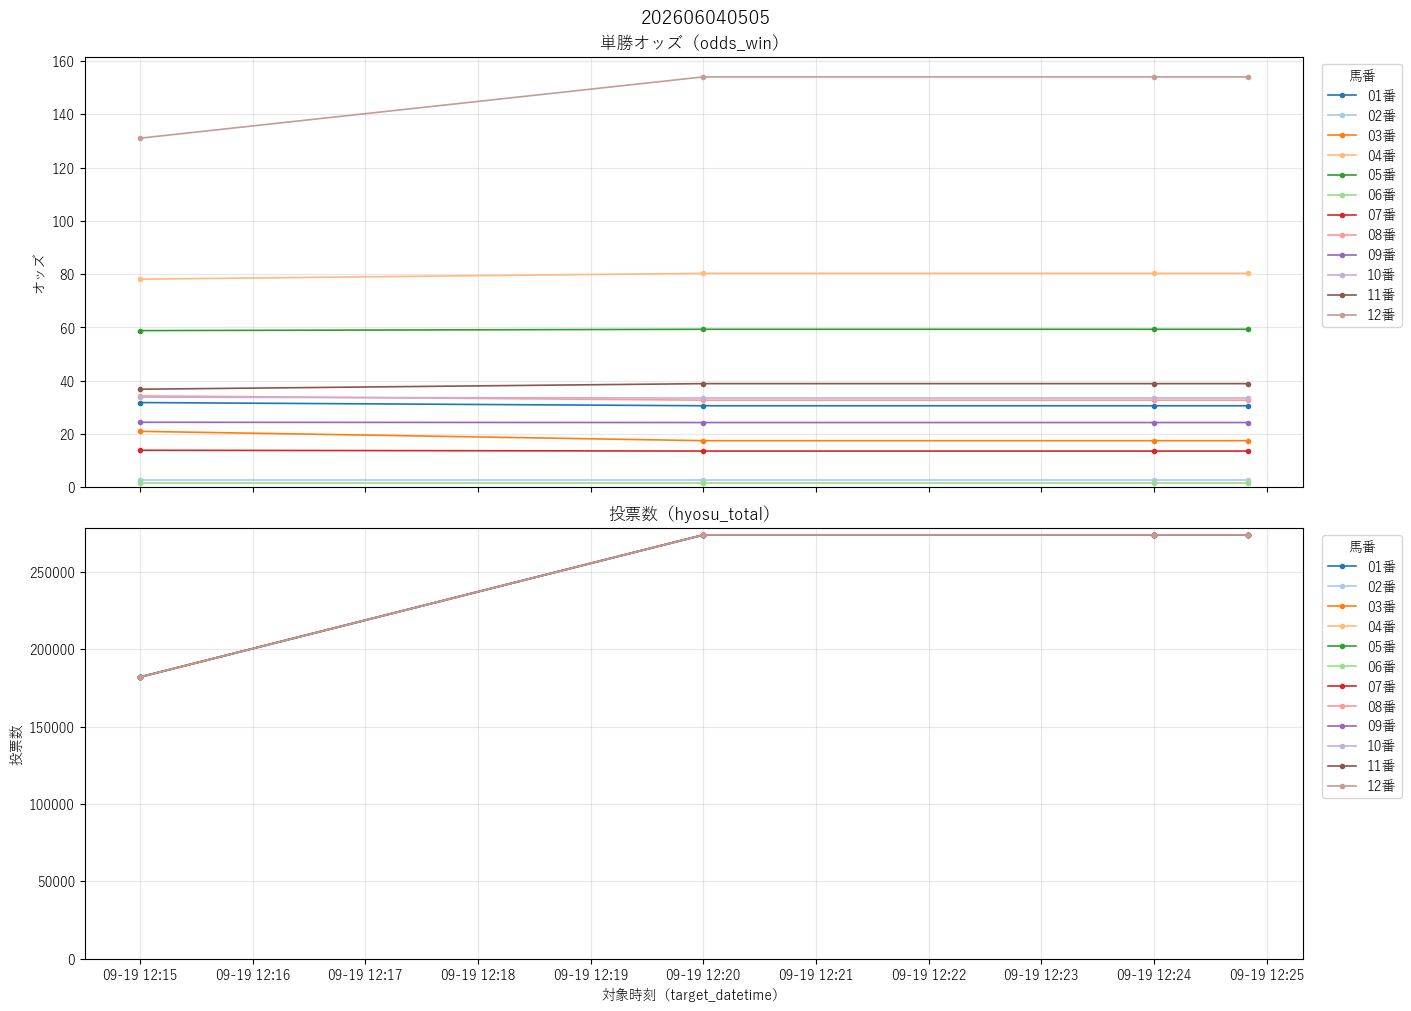

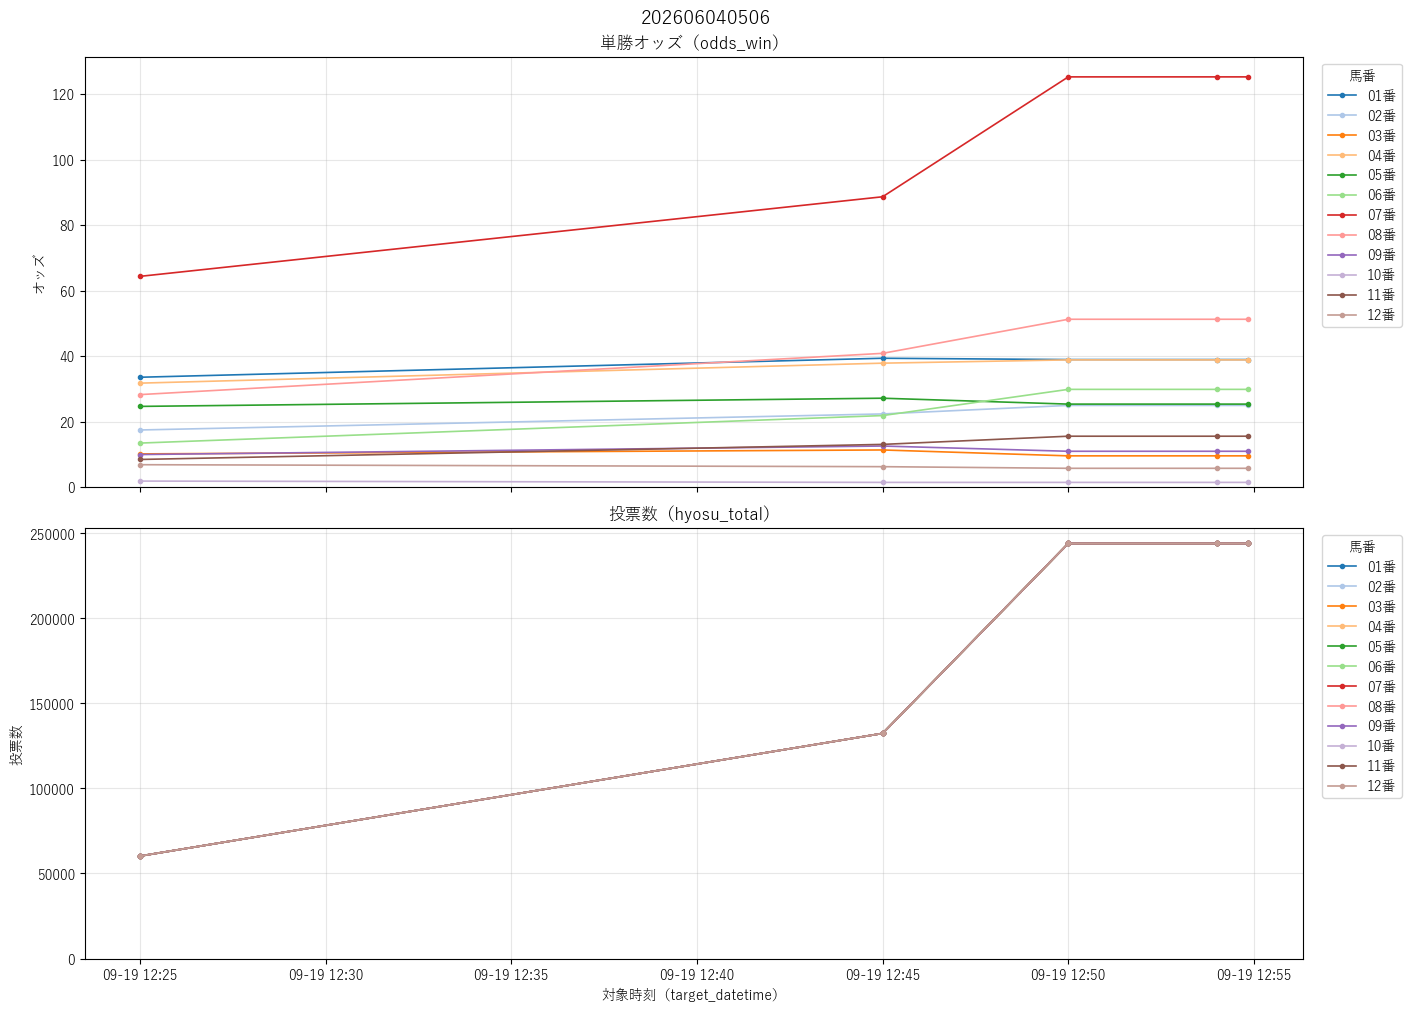

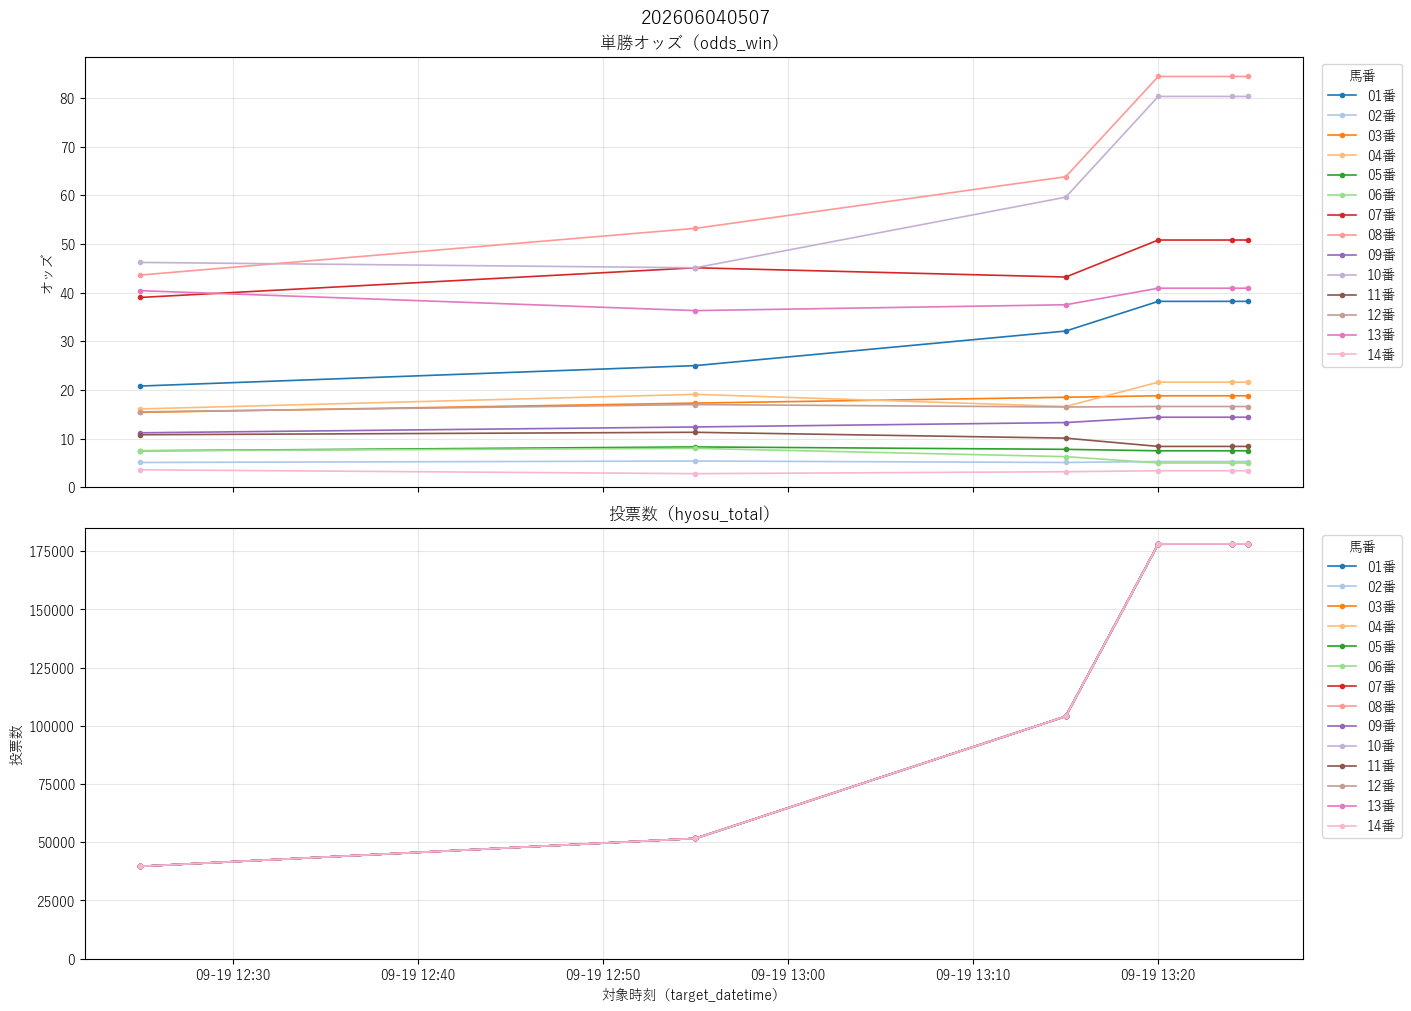

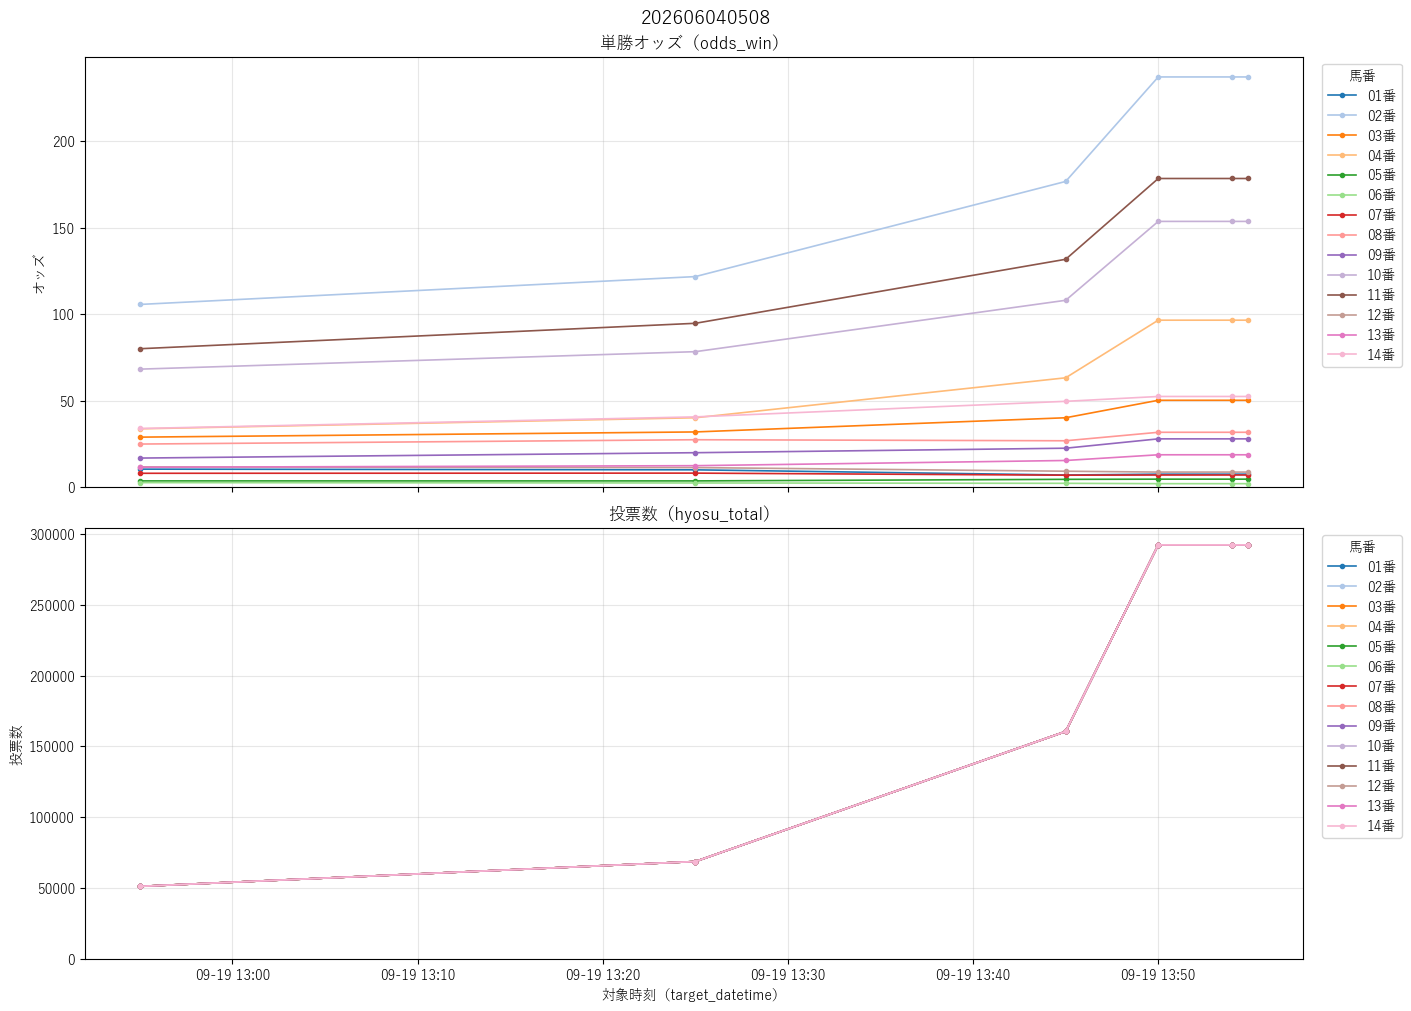

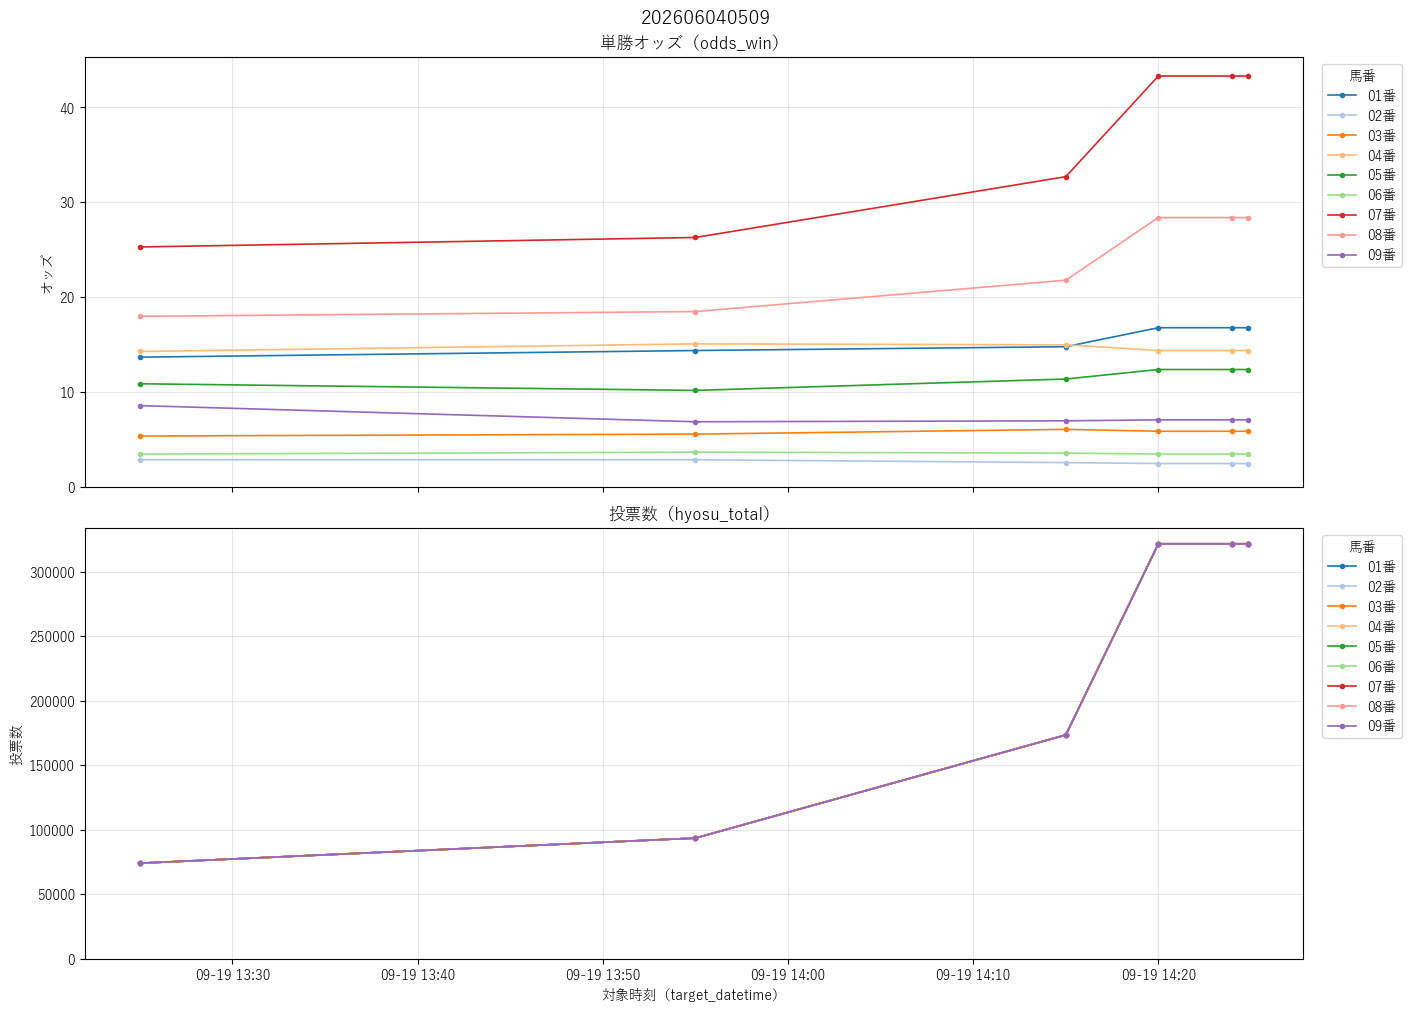

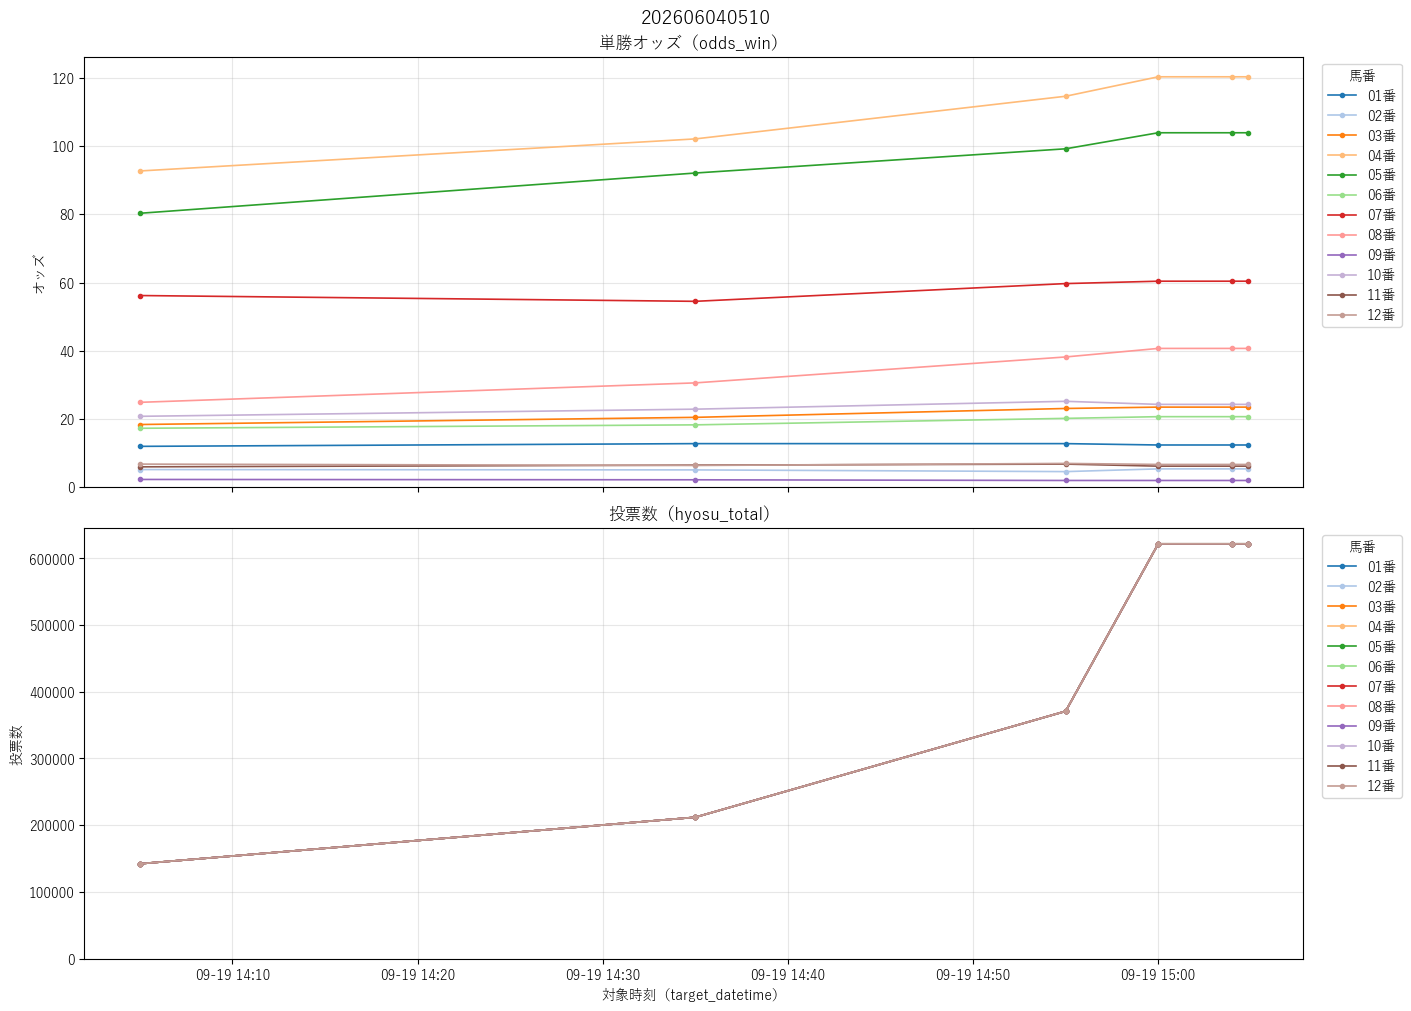

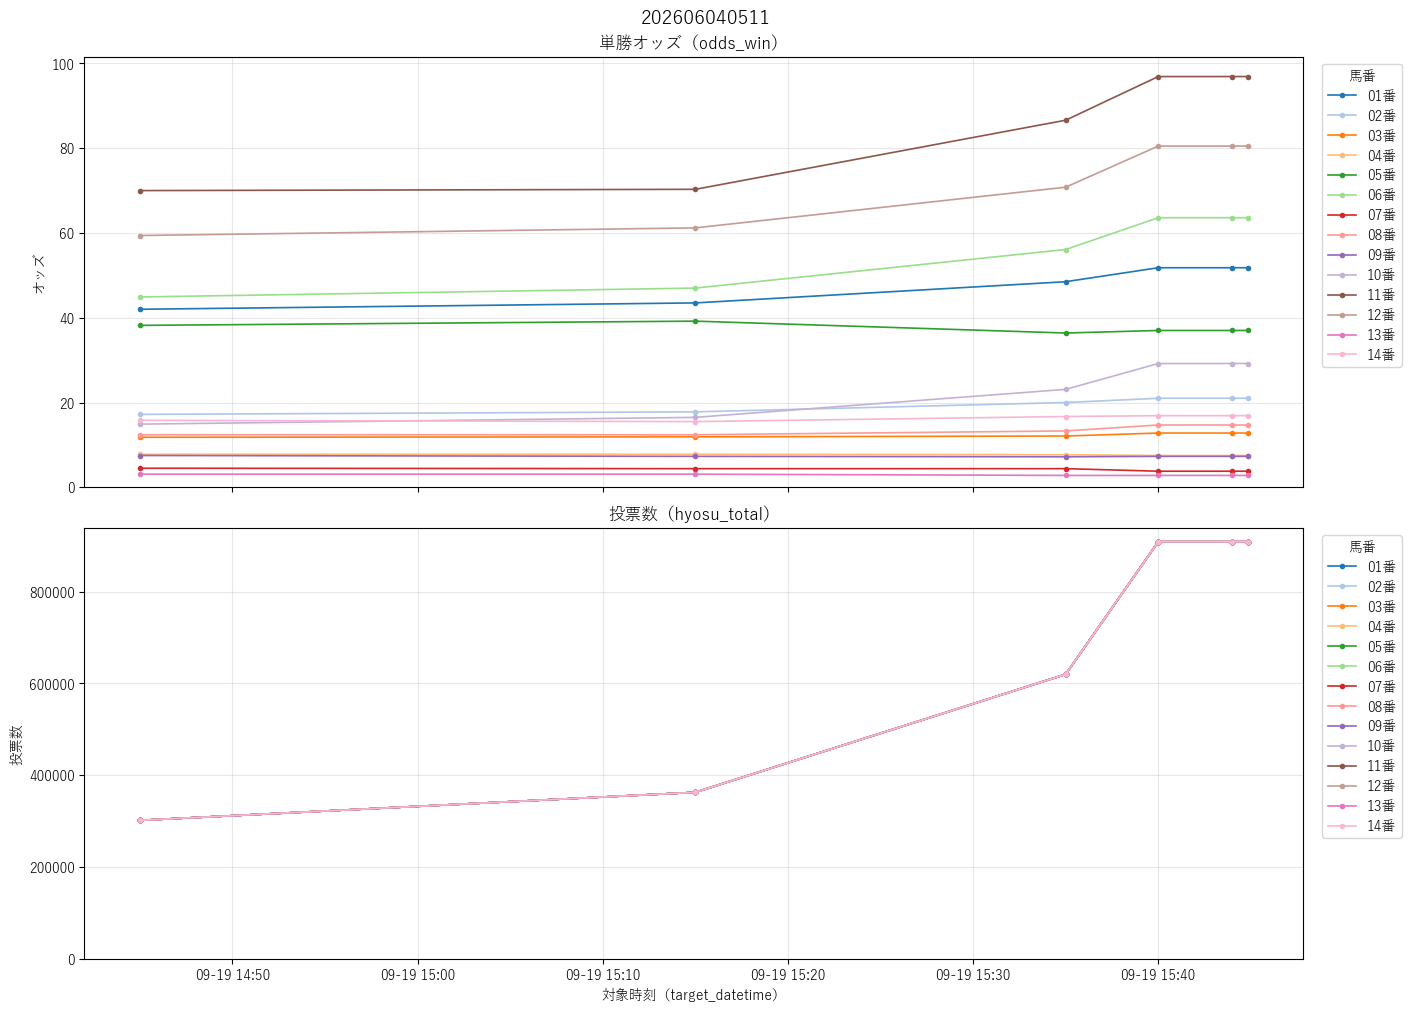

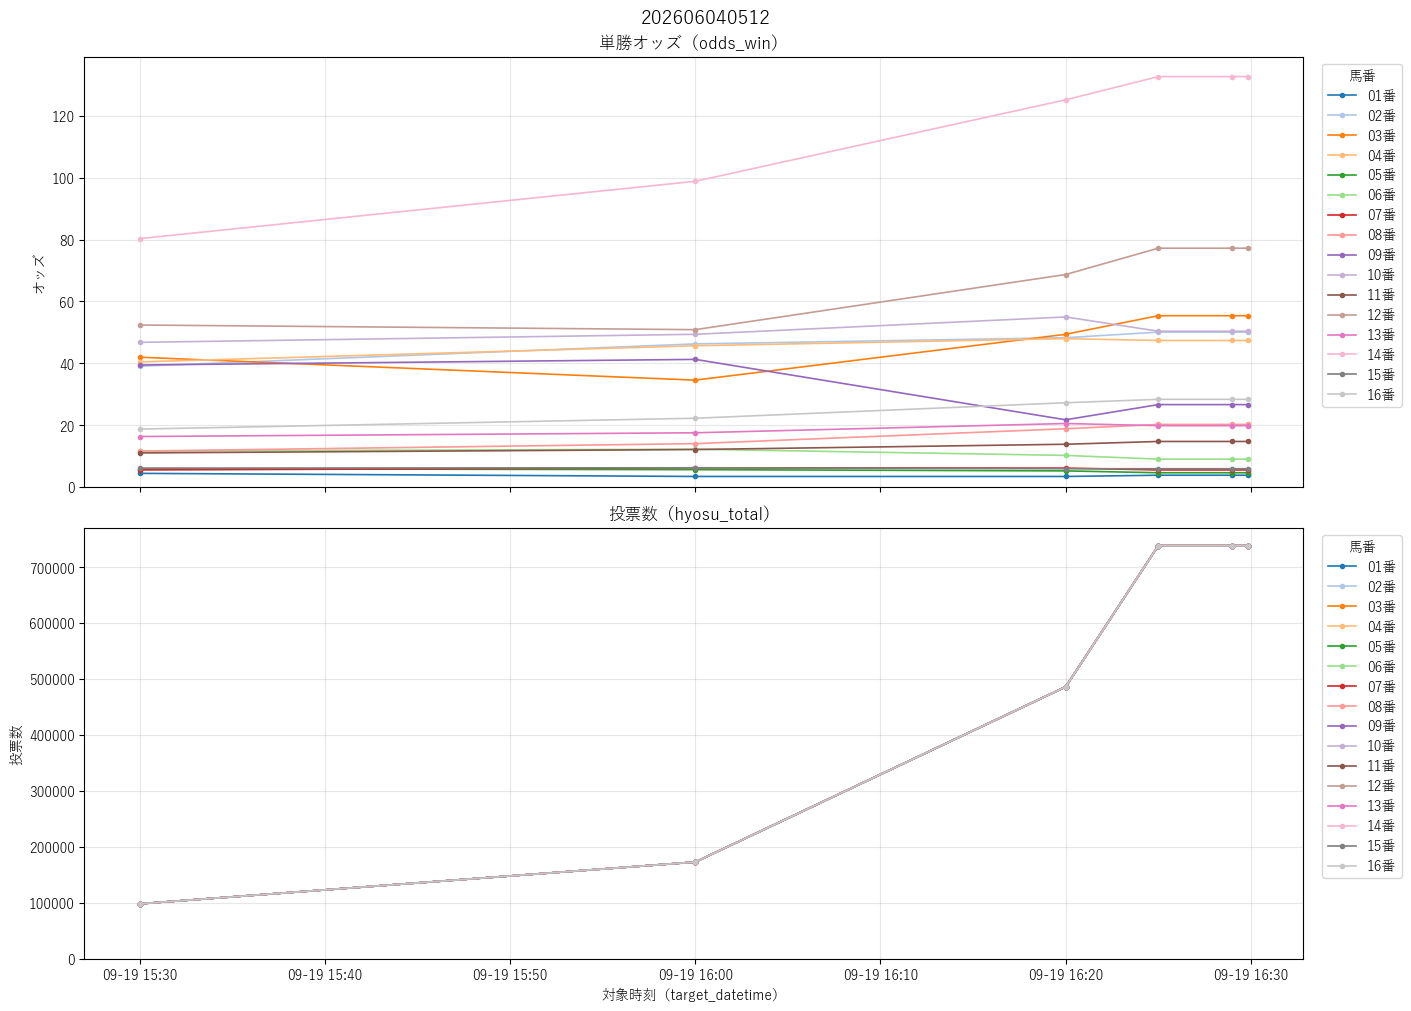

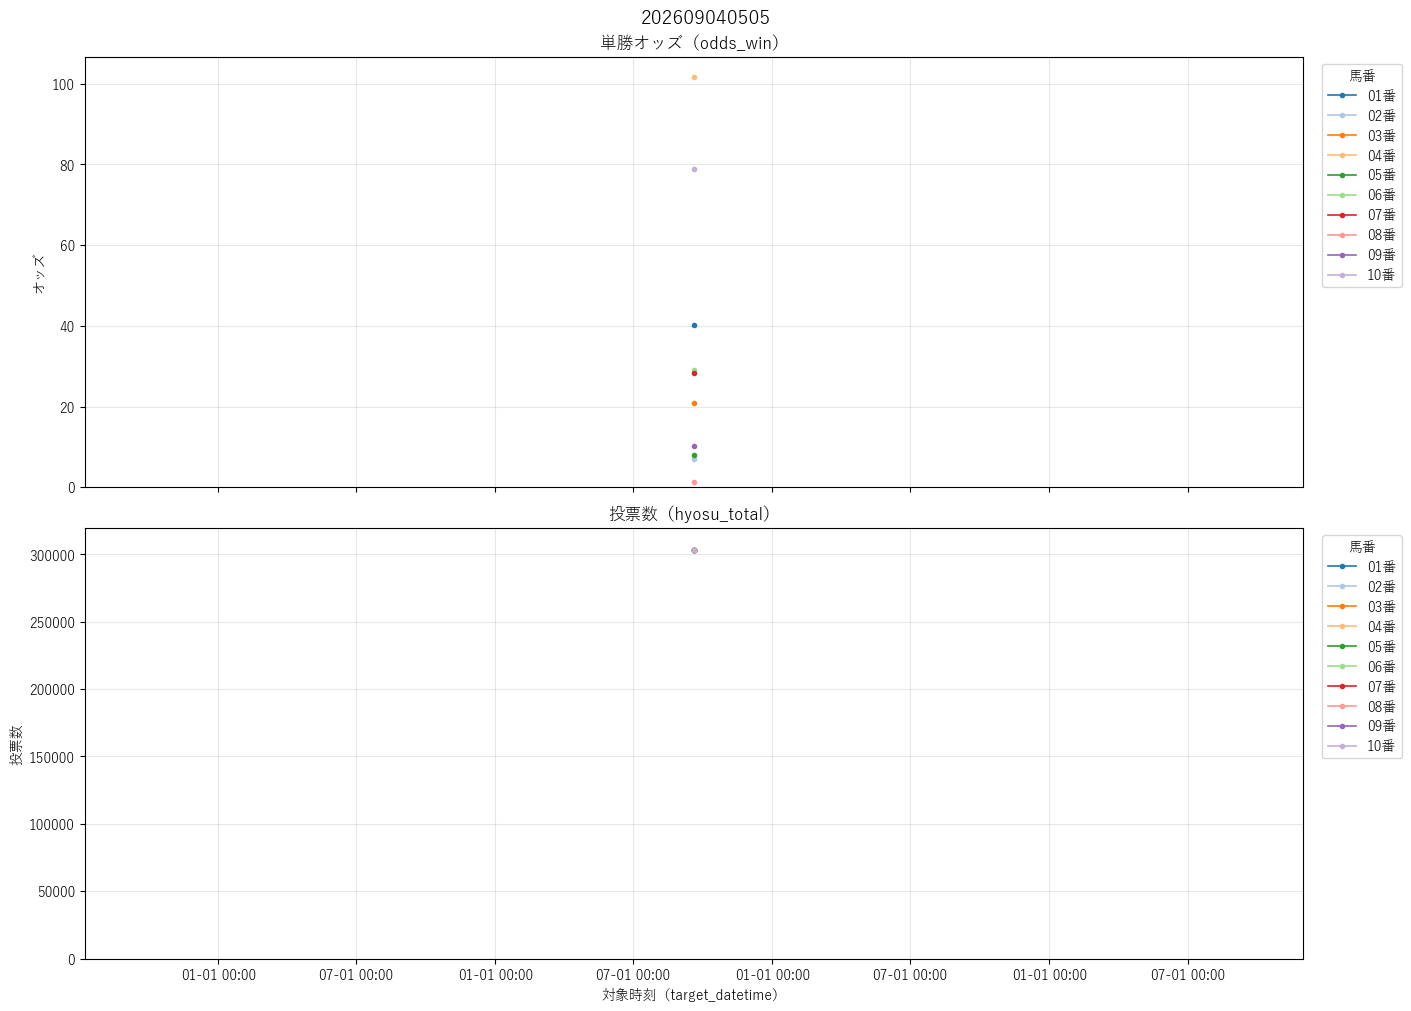

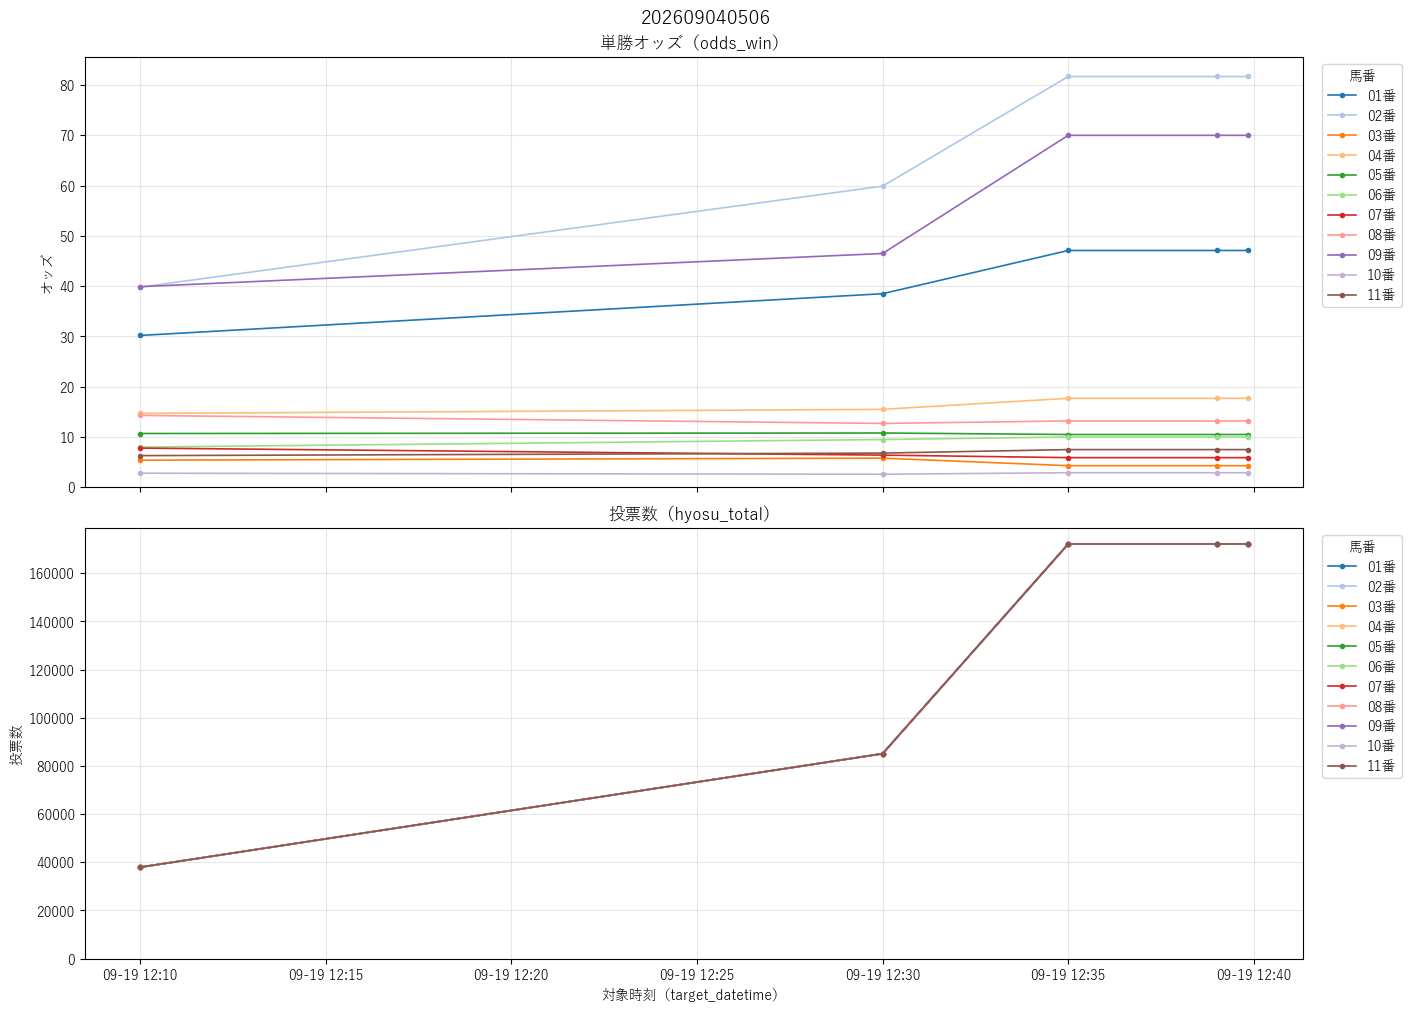

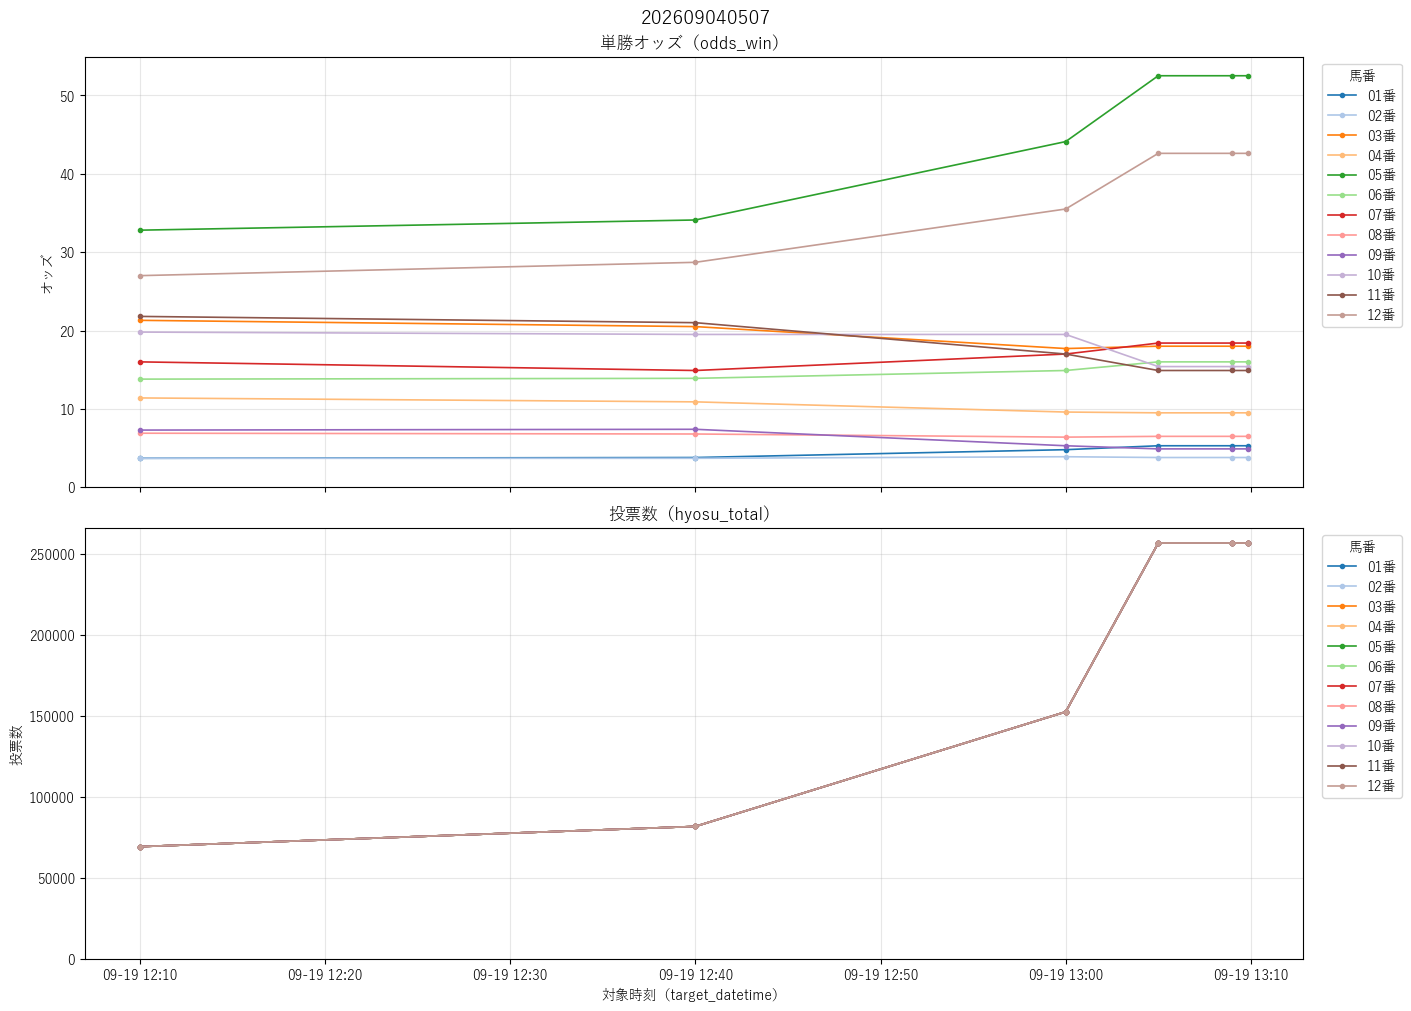

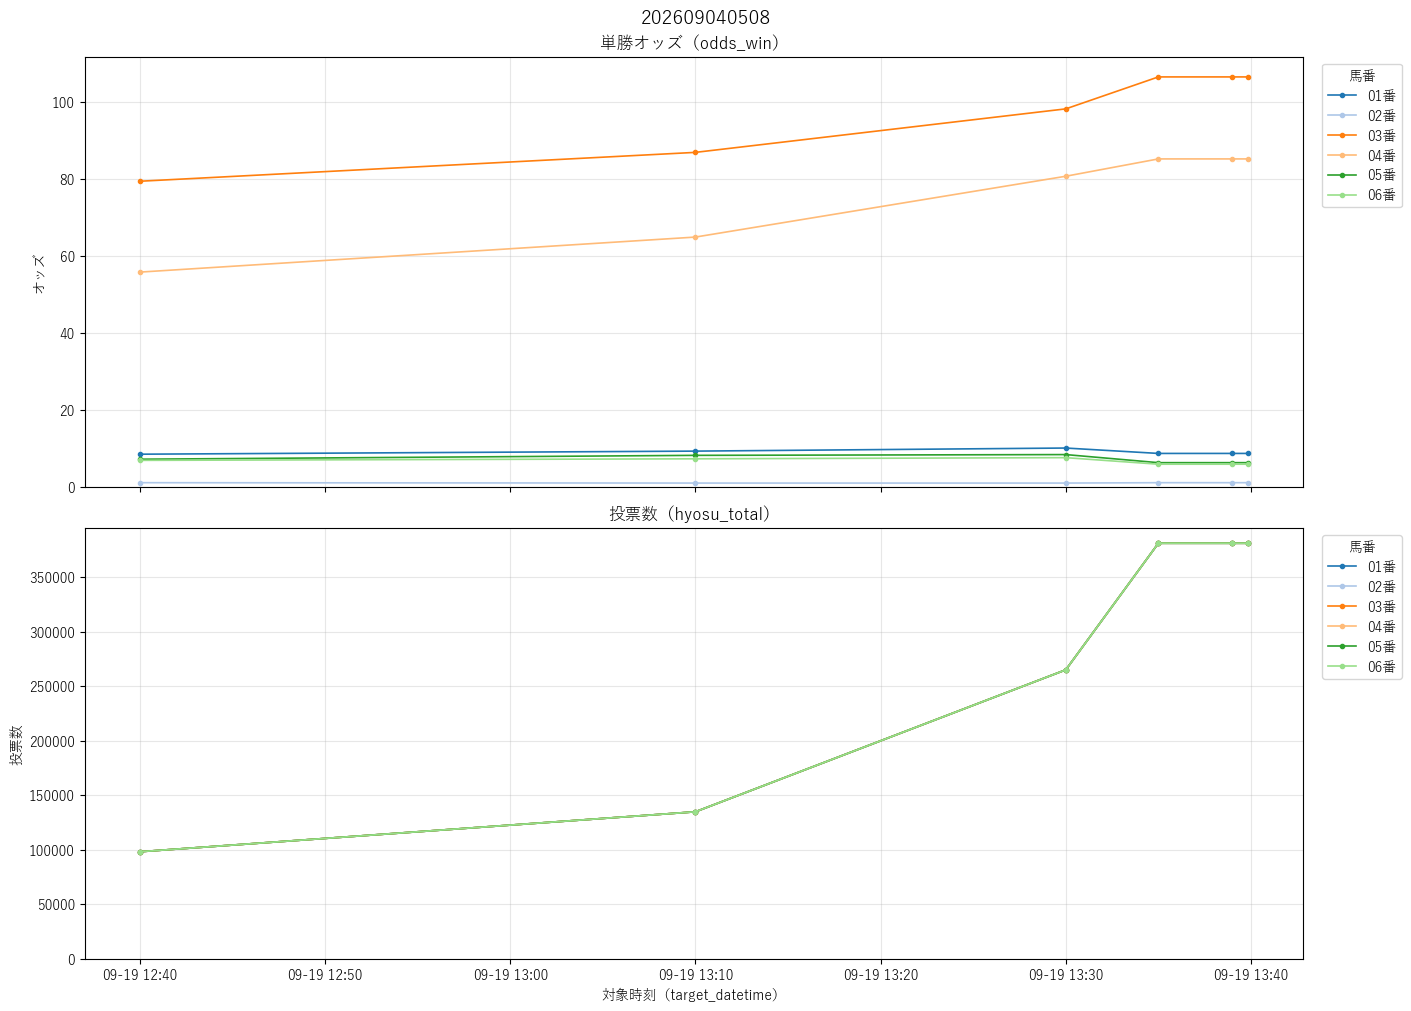

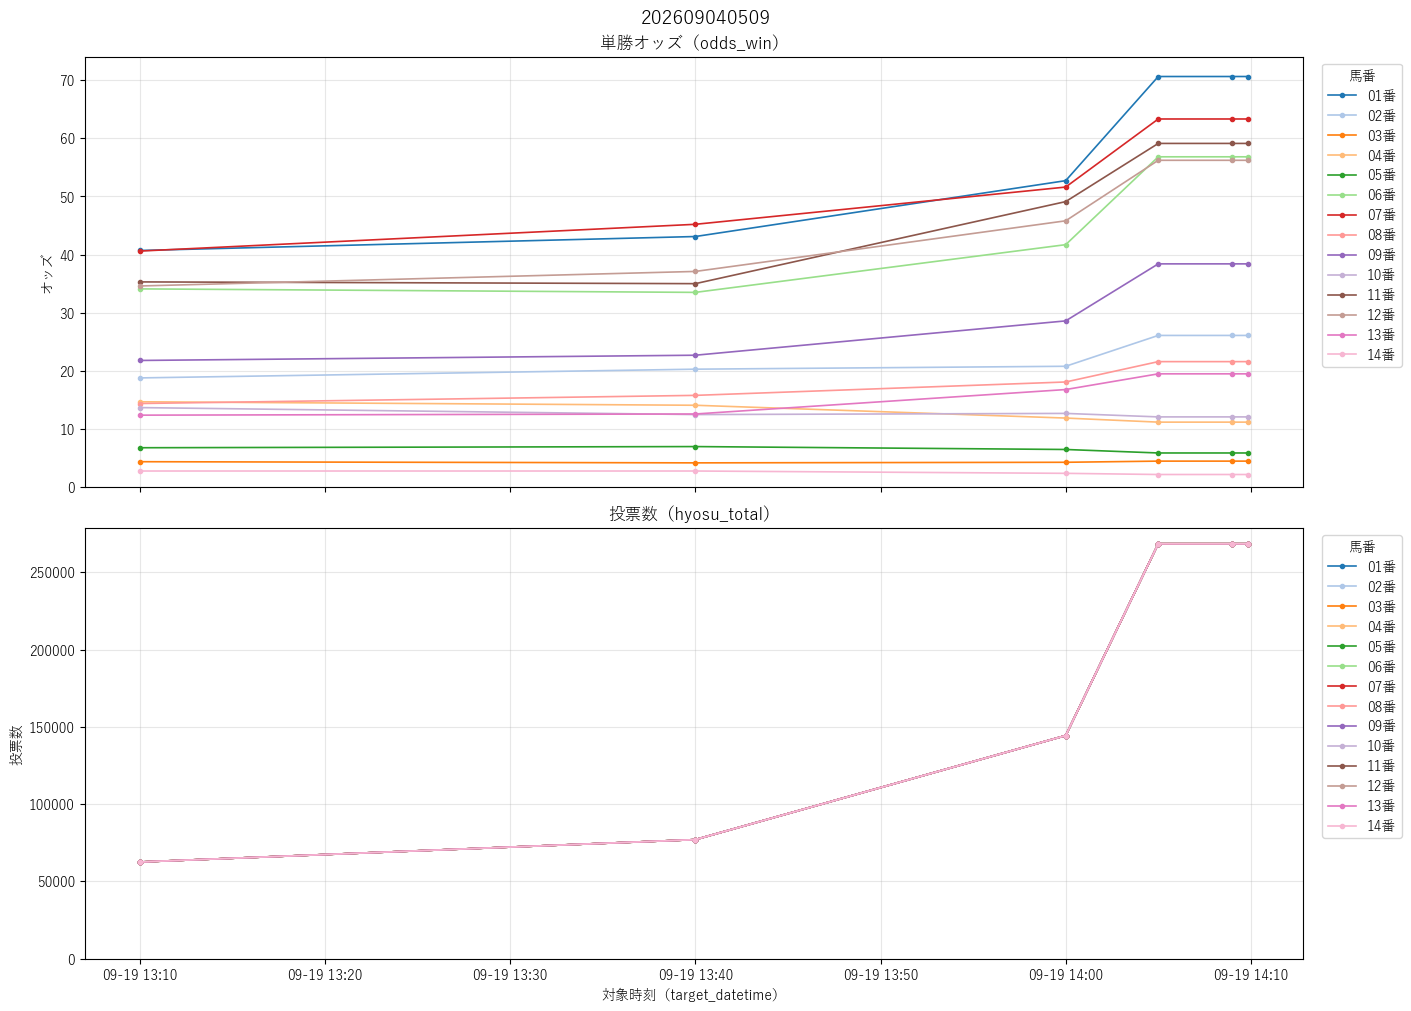

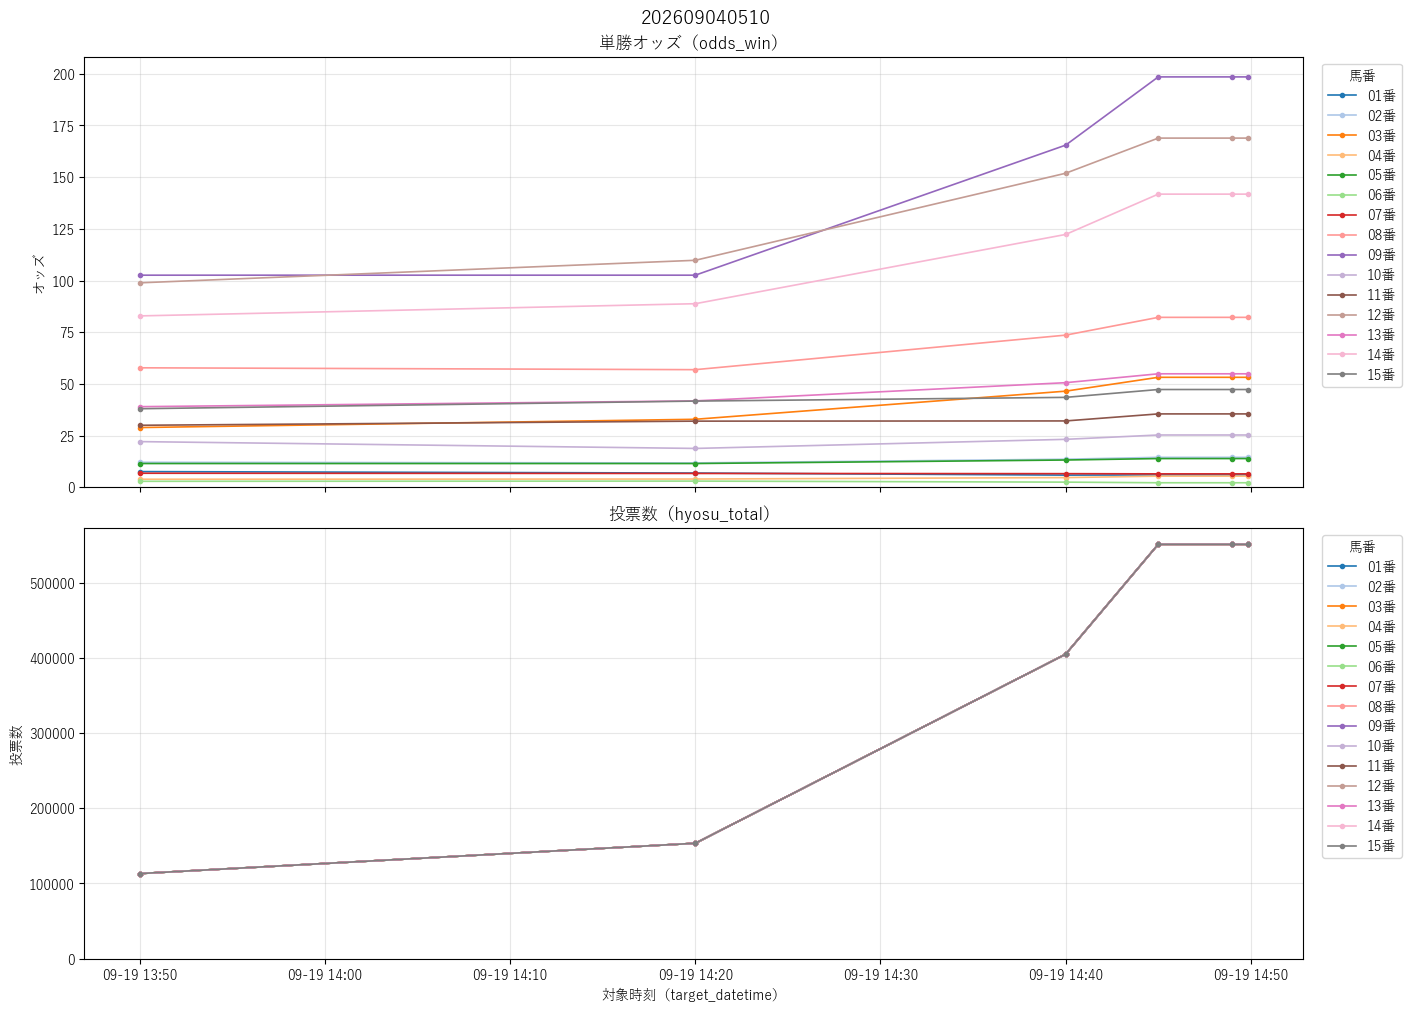

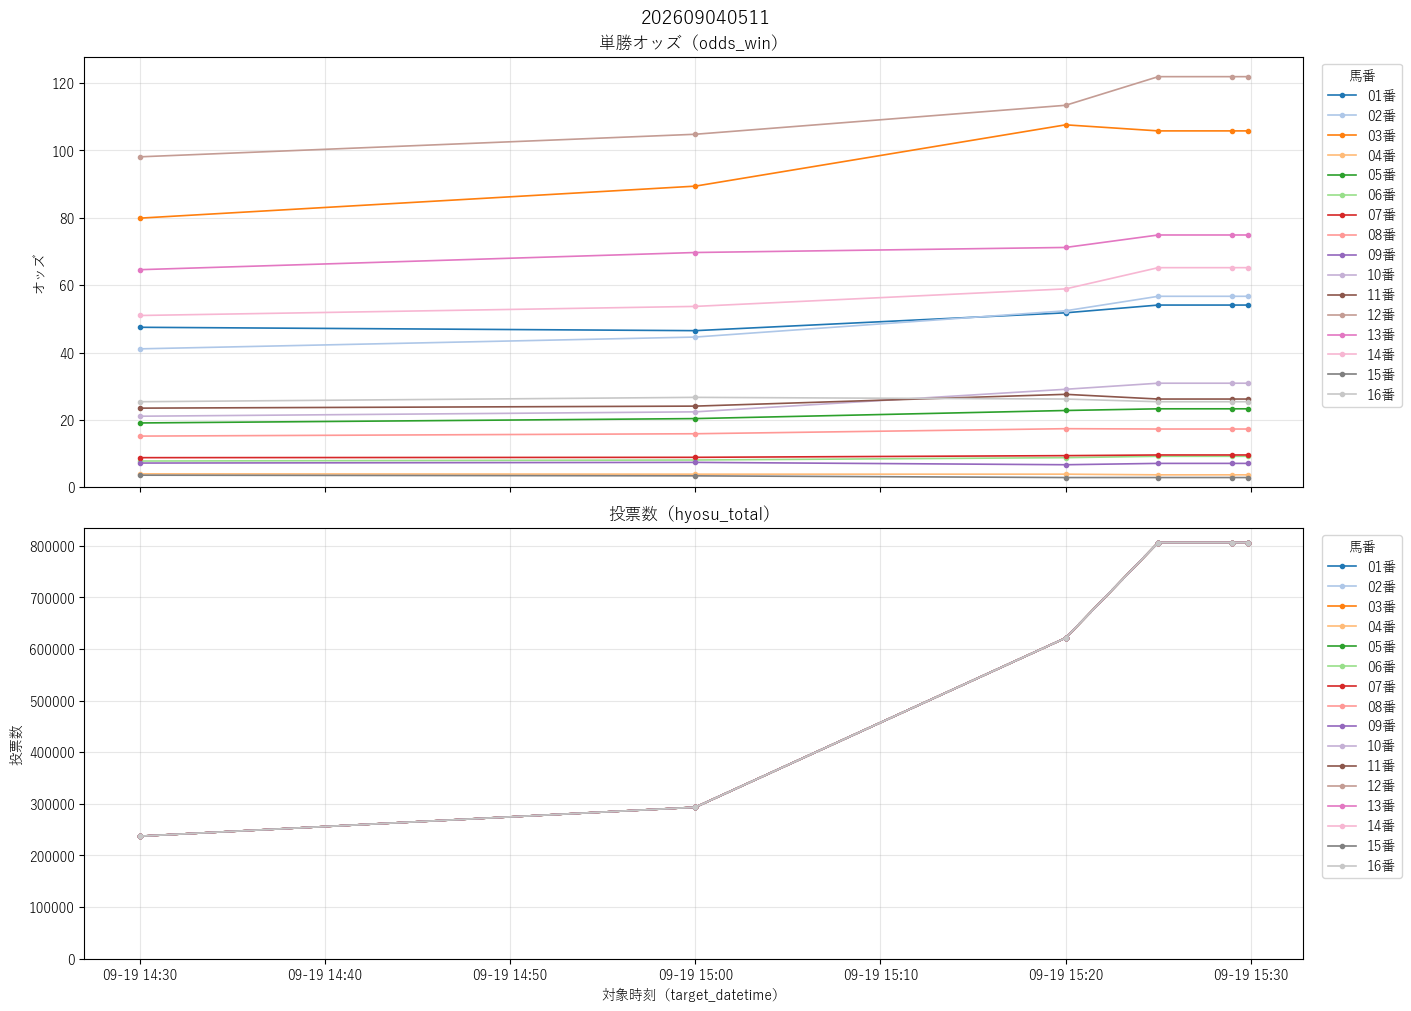

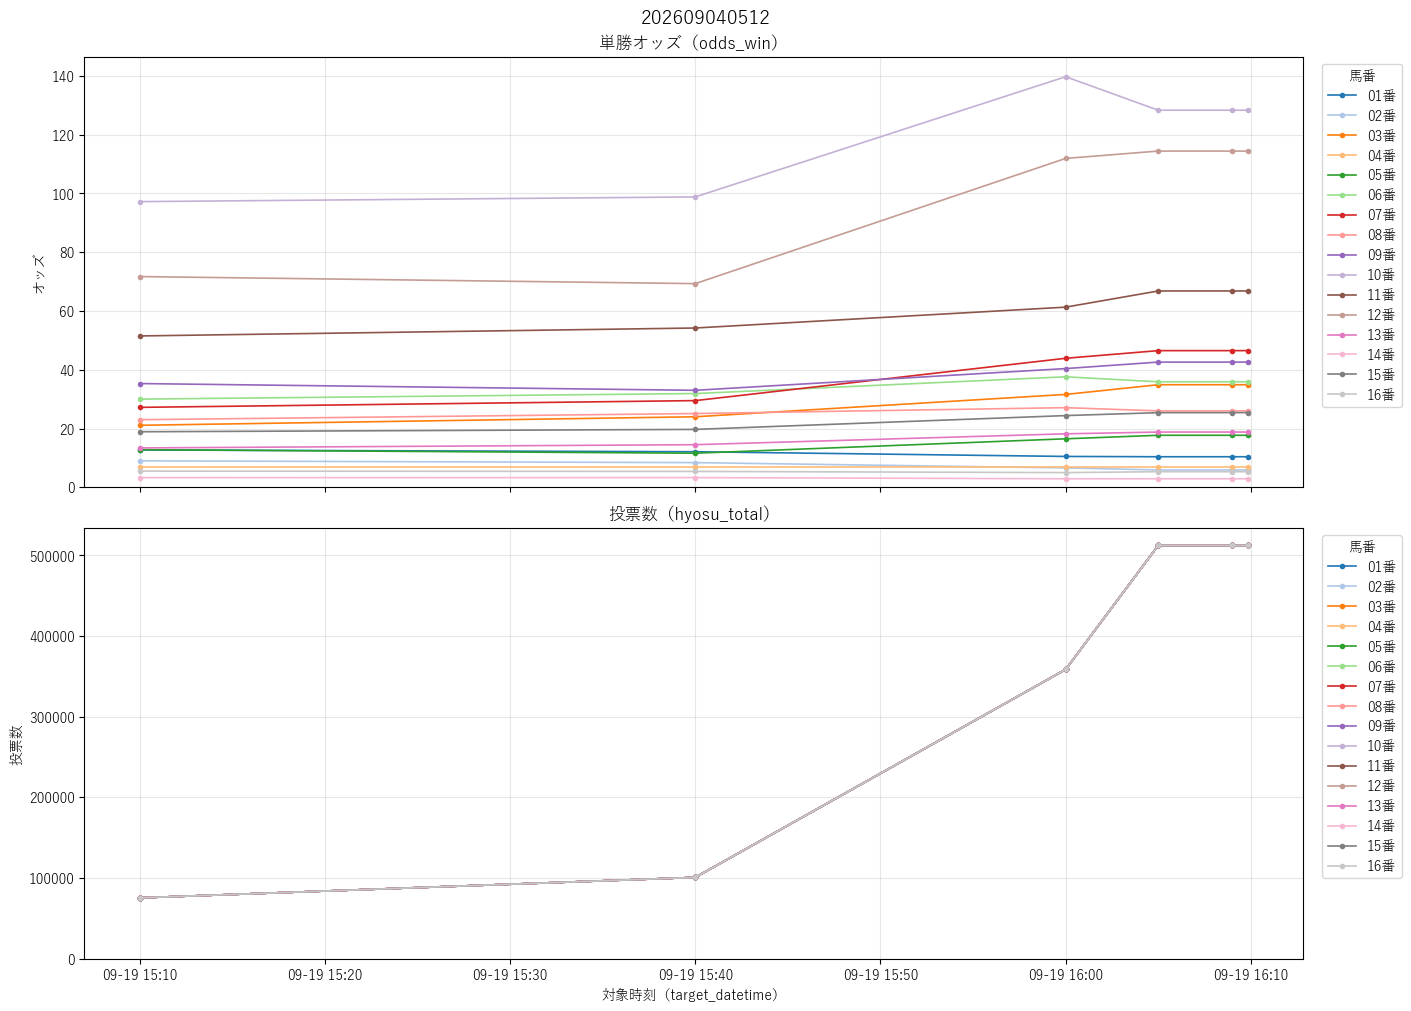

In [12]:
# 任意のレースを指定するとそのレースだけ描画できる。None なら全レースを描画する。
RACE_ID = None

schedule_files = sorted((PROJECT_ROOT / 'data' / 'processed' / '20260919' / 'races').glob('*_jra_today_schedule.csv'))
schedule = pd.DataFrame()
if schedule_files:
    schedule = pd.concat([pd.read_csv(path, dtype={'race_id': str}) for path in schedule_files], ignore_index=True)
    schedule = schedule.drop_duplicates('race_id').set_index('race_id')

def race_title(race_id):
    if race_id in schedule.index:
        row = schedule.loc[race_id]
        return f"{race_id}  {row.get('race_name', '')} (発走 {row.get('post_datetime', '')})"
    return str(race_id)

def plot_race(race_id, race_df):
    race_df = race_df.sort_values(['umaban', 'target_datetime'])
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True, constrained_layout=True)
    colors = plt.cm.tab20.colors
    for index, (umaban, horse_df) in enumerate(race_df.groupby('umaban', sort=True)):
        color = colors[index % len(colors)]
        label = f'{int(umaban):02d}番' if pd.notna(umaban) else '馬番不明'
        axes[0].plot(horse_df['target_datetime'], horse_df['odds_win'], marker='o',
                     markersize=3, linewidth=1.2, color=color, label=label)
        axes[1].plot(horse_df['target_datetime'], horse_df['hyosu_total'], marker='o',
                     markersize=3, linewidth=1.2, color=color, label=label)

    axes[0].set_title('単勝オッズ（odds_win）')
    axes[0].set_ylabel('オッズ')
    axes[0].set_ylim(bottom=0)
    axes[1].set_title('投票数（hyosu_total）')
    axes[1].set_ylabel('投票数')
    axes[1].set_xlabel('対象時刻（target_datetime）')
    axes[1].set_ylim(bottom=0)
    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
        ax.legend(title='馬番', bbox_to_anchor=(1.01, 1), loc='upper left', ncol=1)
    fig.suptitle(race_title(race_id), fontsize=14)
    plt.show()

race_ids = [RACE_ID] if RACE_ID is not None else sorted(df['race_id'].dropna().unique())
for race_id in race_ids:
    race_df = df[df['race_id'] == str(race_id)]
    if race_df.empty:
        print(f'データがありません: {race_id}')
        continue
    plot_race(str(race_id), race_df)